In [1]:
# Cell 1 — Install the GEE Python library
# This only needs to be run once per Colab session
!pip install earthengine-api --quiet

In [2]:
import ee
ee.Authenticate()
ee.Initialize(project='evocative-shore-497608-e7')
print('Hello from GEE!')

Hello from GEE!


In [3]:
# Cell 3 — Install geemap for interactive maps
!pip install geemap --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 47.7 MB/s eta 0:00:00


In [4]:
# Cell 4 — Import libraries and initialize GEE
import ee
import geemap

ee.Authenticate()
ee.Initialize(project='evocative-shore-497608-e7')
print('Libraries loaded successfully')

Libraries loaded successfully


In [5]:
# Cell 5 — Define the Hosur AOI as a rectangle
# Format: ee.Geometry.Rectangle([west, south, east, north])

hosur_aoi = ee.Geometry.Rectangle([
    77.77,  # West boundary (leftmost longitude)
    12.68,  # South boundary (bottommost latitude)
    77.87,  # East boundary (rightmost longitude)
    12.76   # North boundary (topmost latitude)
])

# Print the centroid (centre point) of our AOI
centroid = hosur_aoi.centroid().coordinates().getInfo()
print(f'AOI Centre: Longitude={centroid[0]:.4f}, Latitude={centroid[1]:.4f}')
print(f'AOI Area: {hosur_aoi.area().getInfo()/1e6:.2f} sq. km')

AOI Centre: Longitude=77.8200, Latitude=12.7200
AOI Area: 96.49 sq. km


In [6]:
# Cell 6 — Visualize the AOI on an interactive map
# Create an interactive map centred on Hosur
map1 = geemap.Map(center=[12.72, 77.82], zoom=10)

# Add the AOI boundary to the map (red colour)
map1.addLayer(
    hosur_aoi,
    {'color': 'red'},
    'Hosur AOI Boundary'
)

# Add a satellite basemap for context
map1.add_basemap('SATELLITE')

# Display the interactive map
map1

Map(center=[12.72, 77.82], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright'…

In [7]:
# Cell 7 (FIXED) — Change 2023 to 2022
aod_collection = (
    ee.ImageCollection('MODIS/006/MCD19A2_GRANULES')
    .filterBounds(hosur_aoi)
    .filterDate('2022-01-01', '2022-12-31')  # Changed from 2023 to 2022
    .select('Optical_Depth_047')
)

print('Total MODIS images loaded:', aod_collection.size().getInfo())

Total MODIS images loaded: 1120


In [8]:
# Cell 8 — Apply scale factor (raw values × 0.001 = real AOD)
def apply_scale_factor(image):
    scaled = image.multiply(0.001)
    return scaled.copyProperties(image, ['system:time_start'])

aod_scaled = aod_collection.map(apply_scale_factor)
print('Scale factor applied to all images')

Scale factor applied to all images


In [9]:
# Cell 9 — Compute annual mean AOD and clip to AOI
aod_annual_mean = aod_scaled.mean().clip(hosur_aoi)

stats = aod_annual_mean.reduceRegion(
    reducer=ee.Reducer.minMax(),
    geometry=hosur_aoi,
    scale=1000,
    maxPixels=1e9
)
print('AOD statistics:', stats.getInfo())

AOD statistics: {'Optical_Depth_047_max': 0.7860714285714289, 'Optical_Depth_047_min': 0.5623461538461537}


In [10]:
# Cell 10 — Visualize annual mean AOD map
aod_vis = {
    'min': 0.0,
    'max': 0.8,
    'palette': ['00FF00', 'FFFF00', 'FF8C00', 'FF0000']
    # green → yellow → orange → red
}

map3 = geemap.Map(center=[12.72, 77.82], zoom=11)
map3.add_basemap('SATELLITE')
map3.addLayer(aod_annual_mean, aod_vis, 'Annual Mean AOD 2023')
map3.addLayer(hosur_aoi, {'color': 'white'}, 'Study Area')
map3

Map(center=[12.72, 77.82], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright'…

In [11]:
# Cell 11 — Define seasonal mean function
def get_seasonal_mean(collection, start_month, end_month, label):
    seasonal = collection.filter(
        ee.Filter.calendarRange(start_month, end_month, 'month')
    )
    mean_img = seasonal.mean().clip(hosur_aoi)
    print(f'{label}: {seasonal.size().getInfo()} images used')
    return mean_img

In [12]:
# Cell 12 — Compute all four seasonal means
summer_aod = get_seasonal_mean(aod_scaled, 3, 5, 'Summer (Mar-May)')
monsoon_aod = get_seasonal_mean(aod_scaled, 6, 9, 'Monsoon (Jun-Sep)')
postmon_aod = get_seasonal_mean(aod_scaled, 10, 11, 'Post-Monsoon (Oct-Nov)')
winter_aod = get_seasonal_mean(aod_scaled, 12, 2, 'Winter (Dec-Feb)')

Summer (Mar-May): 273 images used
Monsoon (Jun-Sep): 383 images used
Post-Monsoon (Oct-Nov): 176 images used
Winter (Dec-Feb): 288 images used


In [20]:
# Cell 13 — Display all seasons on one map
map4 = geemap.Map(center=[12.72, 77.82], zoom=11)
map4.add_basemap('SATELLITE')

# Same colour ramp for all seasons for fair comparison
aod_vis = {'min':0.0, 'max':0.8,
           'palette':['00FF00','FFFF00','FF8C00','FF0000']}

# Add each season as a separate toggleable layer
map4.addLayer(summer_aod, aod_vis, 'Summer AOD')
map4.addLayer(monsoon_aod, aod_vis, 'Monsoon AOD')
map4.addLayer(postmon_aod, aod_vis, 'Post-Monsoon AOD')
map4.addLayer(winter_aod, aod_vis, 'Winter AOD')
map4.addLayer(hosur_aoi, {'color':'white'}, 'Study Area')

# Display — use the layer panel (top-right) to toggle seasons
map4


# Show ONLY Winter AOD
map_winter = geemap.Map(center=[12.72, 77.82], zoom=11)
map_winter.add_basemap('SATELLITE')
map_winter.addLayer(winter_aod, aod_vis, 'Winter AOD')
map_winter.addLayer(hosur_aoi, {'color': 'white'}, 'Study Area')
map_winter

Map(center=[12.72, 77.82], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright'…

In [18]:
# Cell 14 — Extract and print seasonal statistics table
seasons = {
    'Summer (Mar-May)': summer_aod,
    'Monsoon (Jun-Sep)': monsoon_aod,
    'Post-Monsoon (Oct-Nov)': postmon_aod,
    'Winter (Dec-Feb)': winter_aod,
}

print('--- Seasonal Mean AOD Values for Hosur 2022 ---')
print(f'{"Season":<25} {"Mean AOD":>10}')
print('-' * 37)

for season_name, img in seasons.items():
    stats = img.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=hosur_aoi,
        scale=1000,
        maxPixels=1e9
    )
    val = stats.getInfo().get('Optical_Depth_047', 'No data')
    if val: print(f'{season_name:<25} {val:>10.4f}')

--- Seasonal Mean AOD Values for Hosur 2022 ---
Season                      Mean AOD
-------------------------------------
Summer (Mar-May)              0.7972
Monsoon (Jun-Sep)             0.7833
Post-Monsoon (Oct-Nov)        0.8001
Winter (Dec-Feb)              0.4777


In [21]:
# Cell 15 — Load Sentinel-5P NO2 Collection
no2_collection = (
    ee.ImageCollection('COPERNICUS/S5P/NRTI/L3_NO2')
    .filterBounds(hosur_aoi)
    .filterDate('2022-01-01', '2022-12-31')  # Same year as AOD
    .select('NO2_column_number_density')
)

print('Sentinel-5P images loaded:', no2_collection.size().getInfo())

Sentinel-5P images loaded: 576


In [24]:
# Cell 16 (FIXED) — Skip quality filter, just compute mean
no2_mean = (
    ee.ImageCollection('COPERNICUS/S5P/NRTI/L3_NO2')
    .filterBounds(hosur_aoi)
    .filterDate('2022-01-01', '2022-12-31')
    .select('NO2_column_number_density')
    .mean()
    .clip(hosur_aoi)
)

print('NO2 annual mean computed (no QA filter)')

NO2 annual mean computed (no QA filter)


In [25]:
# Cell 17 — Visualize NO2 map
no2_vis = {
    'min': 0.00005,
    'max': 0.0002,
    'palette': ['blue', 'purple', 'cyan', 'yellow', 'red']
}

map5 = geemap.Map(center=[12.72, 77.82], zoom=11)
map5.add_basemap('SATELLITE')
map5.addLayer(no2_mean, no2_vis, 'Annual Mean NO2 2022')
map5.addLayer(hosur_aoi, {'color': 'white'}, 'Study Area')
map5

Map(center=[12.72, 77.82], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright'…

In [26]:
# Cell 18 — Create pollution classification map
# Classify AOD into three pollution categories
# Low: AOD < 0.2
# Moderate: AOD 0.2 to 0.5
# High: AOD > 0.5 (hotspots)

low_mask = aod_annual_mean.lt(0.2)
moderate_mask = aod_annual_mean.gte(0.2).And(aod_annual_mean.lt(0.5))
high_mask = aod_annual_mean.gte(0.5)

# Create classified image: 1=Low, 2=Moderate, 3=High
classified = (
    low_mask.multiply(1)
    .add(moderate_mask.multiply(2))
    .add(high_mask.multiply(3))
).clip(hosur_aoi)

print('Pollution classification map created')

Pollution classification map created


In [27]:
# Cell 19 — Visualize hotspots on map
# Create binary hotspot mask (1 = hotspot, 0 = not hotspot)
hotspot_mask = aod_annual_mean.gt(0.5).clip(hosur_aoi)

map6 = geemap.Map(center=[12.72, 77.82], zoom=11)
map6.add_basemap('SATELLITE')

# Add annual AOD as background
map6.addLayer(aod_annual_mean,
              {'min':0, 'max':0.8, 'palette':['00FF00','FFFF00','FF0000']},
              'Annual AOD Background')

# Overlay only hotspot pixels in red
map6.addLayer(
    hotspot_mask.updateMask(hotspot_mask),
    {'palette': ['FF0000']},
    'Pollution Hotspots (AOD > 0.5)'
)

map6.addLayer(hosur_aoi, {'color':'white'}, 'Study Area')
map6

Map(center=[12.72, 77.82], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright'…

In [28]:
# Cell 20 — Calculate area of each pollution zone
def get_zone_area(mask, zone_name):
    area_image = mask.multiply(ee.Image.pixelArea())
    total = area_image.reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=hosur_aoi,
        scale=1000,
        maxPixels=1e9
    )
    area_sqkm = list(total.getInfo().values())[0] / 1e6
    print(f'{zone_name:<25}: {area_sqkm:.2f} sq. km')
    return area_sqkm

print('--- Pollution Zone Area Statistics ---')
low_area = get_zone_area(low_mask, 'Low Pollution (AOD<0.2)')
mod_area = get_zone_area(moderate_mask, 'Moderate (AOD 0.2-0.5)')
high_area = get_zone_area(high_mask, 'High Pollution (AOD>0.5)')

total = low_area + mod_area + high_area
print(f'{"Total Area":<25}: {total:.2f} sq. km')

# Calculate percentage
high_pct = (high_area / total) * 100
print(f'\nPercentage of study area as High Pollution: {high_pct:.2f}%')

--- Pollution Zone Area Statistics ---
Low Pollution (AOD<0.2)  : 0.00 sq. km
Moderate (AOD 0.2-0.5)   : 0.00 sq. km
High Pollution (AOD>0.5) : 95.72 sq. km
Total Area               : 95.72 sq. km

Percentage of study area as High Pollution: 100.00%


In [29]:
# Cell 21 — Extract monthly mean AOD values
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

months = range(1, 13)
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
aod_values = []

print('Extracting monthly AOD values...')
for month in months:
    monthly = aod_scaled.filter(
        ee.Filter.calendarRange(month, month, 'month')
    )
    monthly_mean = monthly.mean().clip(hosur_aoi)
    stats = monthly_mean.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=hosur_aoi,
        scale=1000, maxPixels=1e9
    )
    val = stats.getInfo().get('Optical_Depth_047', None)
    aod_values.append(round(val, 4) if val else None)
    print(f'  {month_names[month-1]}: {val:.4f}' if val else f'  {month_names[month-1]}: No data')

Extracting monthly AOD values...
  Jan: 0.4911
  Feb: 0.5329
  Mar: 0.6723
  Apr: 0.9144
  May: 0.8692
  Jun: 0.9017
  Jul: No data
  Aug: No data
  Sep: 0.3992
  Oct: 0.5963
  Nov: 1.0571
  Dec: 0.3591


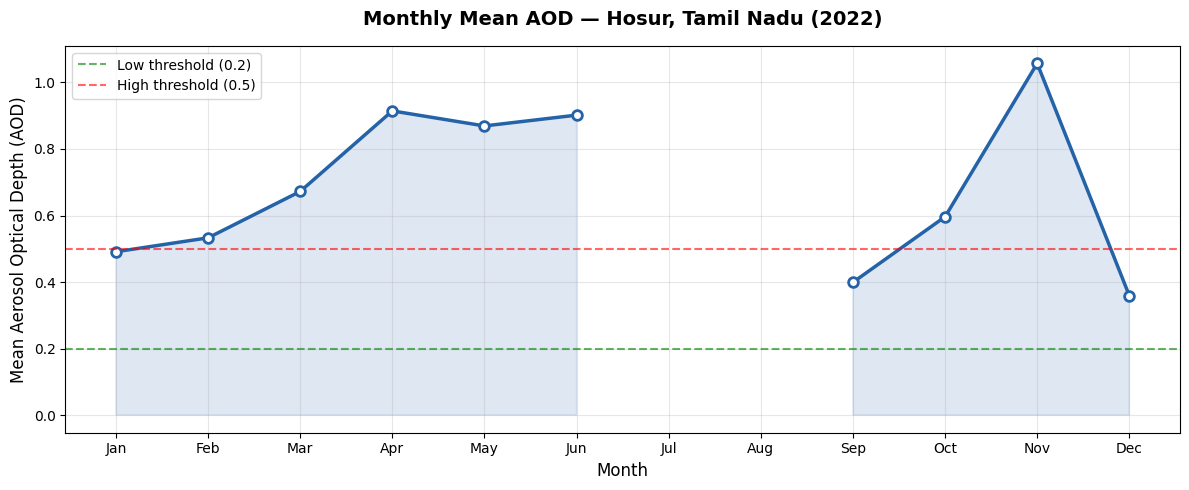

Chart saved!


In [32]:
# Cell 22 — Create and save the time-series chart (FIXED)
import numpy as np

# Convert None values to NaN for plotting
aod_values_clean = [v if v is not None else np.nan for v in aod_values]

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(month_names, aod_values_clean, color='#2563A8',
        linewidth=2.5, marker='o', markersize=7,
        markerfacecolor='white', markeredgewidth=2)

# Fill only where data exists (skip NaN values)
ax.fill_between(range(12), aod_values_clean, alpha=0.15, color='#2563A8')

# Add threshold lines
ax.axhline(y=0.2, color='green', linestyle='--', alpha=0.6, label='Low threshold (0.2)')
ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.6, label='High threshold (0.5)')

ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Mean Aerosol Optical Depth (AOD)', fontsize=12)
ax.set_title('Monthly Mean AOD — Hosur, Tamil Nadu (2022)', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(range(12))
ax.set_xticklabels(month_names)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/monthly_aod_hosur_2022.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved!')

In [33]:
# Cell 23 — Save data as CSV table
df = pd.DataFrame({
    'Month': month_names,
    'Mean_AOD': aod_values
})

def classify_aod(val):
    if val is None: return 'No Data'
    if val < 0.2: return 'Low'
    if val < 0.5: return 'Moderate'
    return 'High'

df['Pollution_Level'] = df['Mean_AOD'].apply(classify_aod)
print(df.to_string(index=False))

df.to_csv('/content/monthly_aod_hosur_2022.csv', index=False)
print('CSV saved!')

Month  Mean_AOD Pollution_Level
  Jan    0.4911        Moderate
  Feb    0.5329            High
  Mar    0.6723            High
  Apr    0.9144            High
  May    0.8692            High
  Jun    0.9017            High
  Jul       NaN            High
  Aug       NaN            High
  Sep    0.3992        Moderate
  Oct    0.5963            High
  Nov    1.0571            High
  Dec    0.3591        Moderate
CSV saved!


In [34]:
# Cell 24 — Export annual mean AOD as GeoTIFF
export_aod = ee.batch.Export.image.toDrive(
    image=aod_annual_mean,
    description='Hosur_Annual_Mean_AOD_2022',
    folder='P5_AirQuality_Outputs',
    fileNamePrefix='hosur_aod_annual_2022',
    scale=1000,
    region=hosur_aoi,
    crs='EPSG:4326',
    maxPixels=1e9
)
export_aod.start()
print('AOD export task started — check Google Drive in a few minutes')

AOD export task started — check Google Drive in a few minutes


In [35]:
# Cell 25 — Export hotspot map as GeoTIFF
export_hotspot = ee.batch.Export.image.toDrive(
    image=hotspot_mask,
    description='Hosur_Pollution_Hotspots_2022',
    folder='P5_AirQuality_Outputs',
    fileNamePrefix='hosur_hotspots_2022',
    scale=1000,
    region=hosur_aoi,
    crs='EPSG:4326',
    maxPixels=1e9
)
export_hotspot.start()
print('Hotspot export task started')

Hotspot export task started


In [36]:
# Cell 26 — Export PNG map thumbnail
thumbnail_url = aod_annual_mean.getThumbURL({
    'min': 0,
    'max': 0.8,
    'palette': ['00FF00', 'FFFF00', 'FF8C00', 'FF0000'],
    'region': hosur_aoi,
    'dimensions': 800
})

import requests
response = requests.get(thumbnail_url)
with open('/content/hosur_aod_annual_2022.png', 'wb') as f:
    f.write(response.content)
print('PNG saved!')

PNG saved!
